# Tarea 7. Usar APIs en la nube



Alonso Pedrero Martínez	
A01769076


Cómputo en la nube

Grupo 10


In [1]:
import os
import json
import requests
from PIL import Image, ImageDraw
from io import BytesIO
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [2]:
load_dotenv()

True

## Face recognition API

In [3]:
faceRecognitionKey = os.getenv("FACE_RECOGNITION_KEY")
faceRecognitionEndPoint = os.getenv("FACE_API_URL")
faceRecognitionEndPoint = faceRecognitionEndPoint + "/face/v1.0/detect"
apiRegion = os.getenv("API_REGION")
translatorEndPoint = os.getenv("TRANSLATE_API_URL")

In [4]:
print(translatorEndPoint)

https://api.cognitive.microsofttranslator.com/translate


In [5]:
def face_recognition_api(image_link : str):
    """
    This function ingests a public photo url and shows 
    rectangles on the recognized persons faces using the Azure API
    """
    # Configuración de la clave a utilizar
    headers = {'Ocp-Apim-Subscription-Key': faceRecognitionKey}

    # Parámtros para la solicitud al servicio
    params = {
        'returnFaceId': 'false',
        'returnFaceLandmarks': 'true'
    }

    # Llamada al servicio
    response = requests.post(faceRecognitionEndPoint, params=params, headers=headers, json={"url": image_link})

    # Almacenar el resultado en formato JSON
    faces = response.json()

    # Mostrar el resultado como texto
    json.dumps(faces)

    # Descargar los datos de la imagen
    img_data = requests.get(image_link)
    # Crear un objeto para poder dibujar la foto
    img = Image.open(BytesIO(img_data.content))

    # Nuevo objeto para poder dibujar figuras sobre la foto
    draw = ImageDraw.Draw(img)

    # Mostrar un rectángulo alrededor de las caras detectadas
    for face in faces:
        rect = face['faceRectangle']
        left = rect['left']
        top = rect['top']
        right = left + rect['width']
        bottom = top + rect['height']
        draw.rectangle([left, top, right, bottom], outline='red', width=3)

    # Formateo de la imagen resultante
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{len(faces)} face(s) detected")
    plt.show()

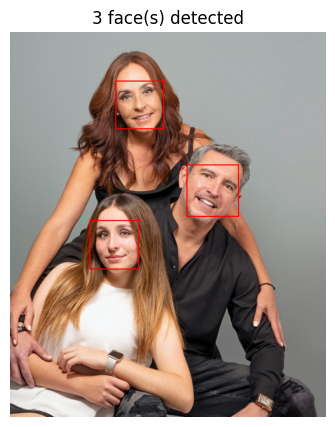

In [6]:
image_url = "https://sesiondefotos.mx/wp-content/uploads/2024/05/sesion-de-fotos-familiar-cdmx-840x1024.jpg"
face_recognition_api(image_url)

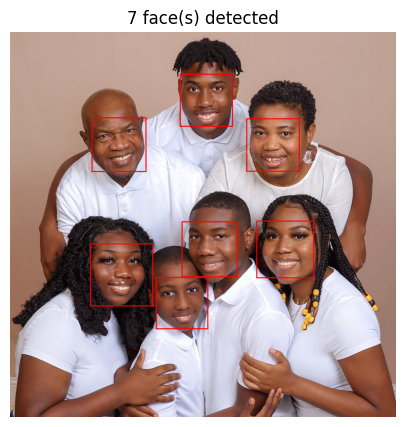

In [7]:
image_url = "https://jcpportraits.com/wp-content/uploads/2025/08/254-008-JCP-Generational-Photography-Gallery-Image-2.jpg"
face_recognition_api(image_url)

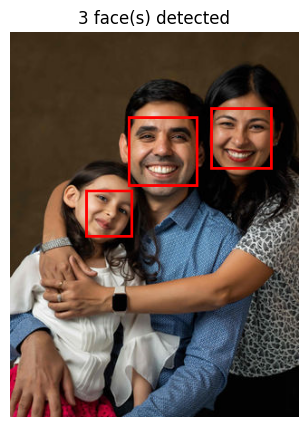

In [8]:
image_url = "https://static.wixstatic.com/media/46ccc2_af7aa625e1174893a2a7db036ba935c6~mv2.jpg/v1/fill/w_319,h_425,q_90,enc_avif,quality_auto/46ccc2_af7aa625e1174893a2a7db036ba935c6~mv2.jpg"
face_recognition_api(image_url)

## Second API

In [9]:
def translate_text_api(text: str, target_language: str):
    """
    This function sends text to Azure Translator API
    and returns the translated text.
    """
    params = {
        "api-version": "3.0",
        "to": target_language
    }

    headers = {
        "Ocp-Apim-Subscription-Key": faceRecognitionKey,
        "Ocp-Apim-Subscription-Region": apiRegion,
        "Content-Type": "application/json"
    }

    body = [
        {"text": text}
    ]

    response = requests.post(translatorEndPoint, params=params, headers=headers, json=body)

    result = response.json()

    print(json.dumps(result, indent=2))

    translated_text = result[0]["translations"][0]["text"]

    return translated_text

In [10]:
translate_text_api("Hola, mi nombre es Alonso", "en")

[
  {
    "detectedLanguage": {
      "language": "es",
      "score": 0.52
    },
    "translations": [
      {
        "text": "Hello, my name is Alonso",
        "to": "en"
      }
    ]
  }
]


'Hello, my name is Alonso'

In [11]:
translate_text_api("Hola, mi nombre es Alonso", "fr")

[
  {
    "detectedLanguage": {
      "language": "es",
      "score": 0.52
    },
    "translations": [
      {
        "text": "Bonjour, je m\u2019appelle Alonso",
        "to": "fr"
      }
    ]
  }
]


'Bonjour, je m’appelle Alonso'

In [12]:
translate_text_api("Hola, mi nombre es Alonso", "ja")

[
  {
    "detectedLanguage": {
      "language": "es",
      "score": 0.52
    },
    "translations": [
      {
        "text": "\u3053\u3093\u306b\u3061\u306f\u3001\u79c1\u306e\u540d\u524d\u306f\u30a2\u30ed\u30f3\u30bd\u3067\u3059",
        "to": "ja"
      }
    ]
  }
]


'こんにちは、私の名前はアロンソです'